
  0%|                         | 0.00/9.70M [00:00<?, ?B/s]


 29%|████▌           | 2.79M/9.70M [00:00<00:00, 27.7MB/s]


 65%|██████████▍     | 6.32M/9.70M [00:00<00:00, 26.5MB/s]


 96%|███████████████▎| 9.27M/9.70M [00:00<00:00, 27.6MB/s]


100%|████████████████| 9.70M/9.70M [00:00<00:00, 27.6MB/s]

...

Epoch [7/10], Loss: 0.0565, Train Acc: 98.73%, Val Acc: 98.14%


Epoch [8/10], Loss: 0.0521, Train Acc: 98.77%, Val Acc: 98.58%


Epoch [9/10], Loss: 0.0383, Train Acc: 99.07%, Val Acc: 98.57%


Epoch [10/10], Loss: 0.0422, Train Acc: 99.02%, Val Acc: 98.90%


Accuracy on QMNIST test set: 98.91%


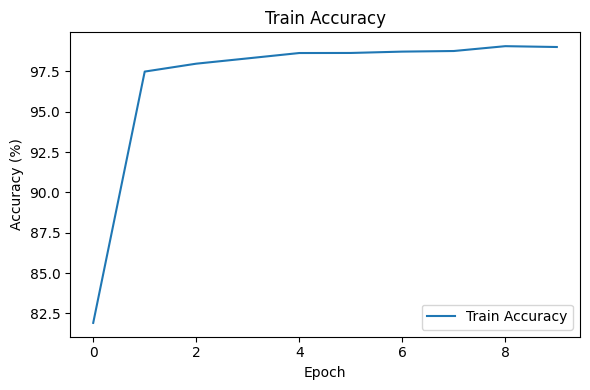

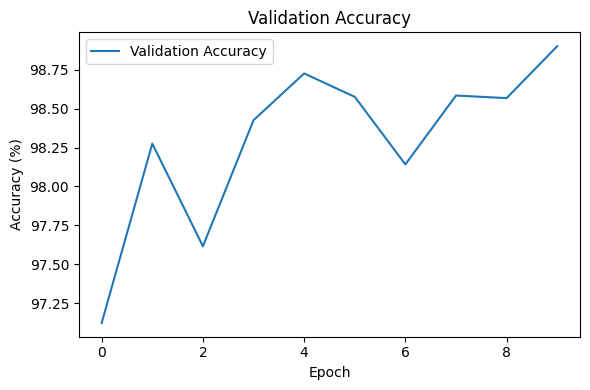

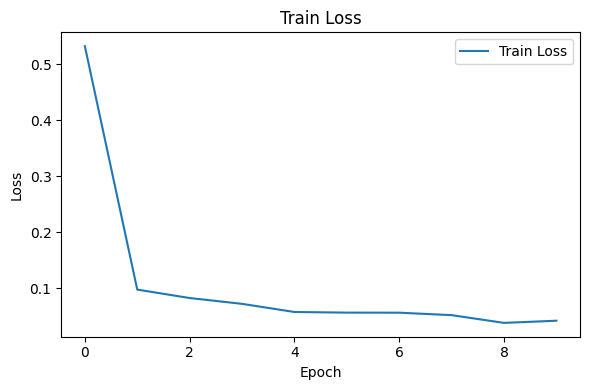

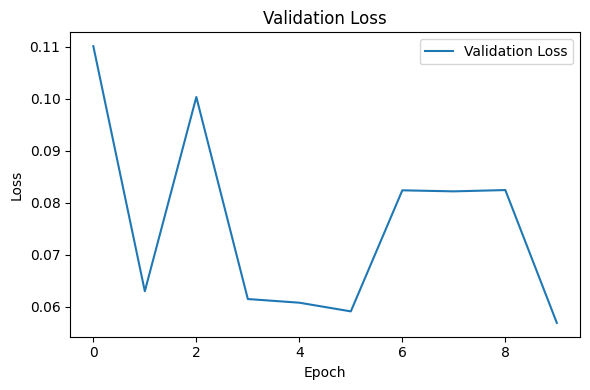

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

num_epochs = 10
batch_size = 128
learning_rate = 0.001

# Dataset
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.QMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.QMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# CaffeNet Model
class CaffeNet(nn.Module):
    def __init__(self):
        super(CaffeNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 96, 11, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),

            nn.Conv2d(96, 256, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),

            nn.Conv2d(256, 384, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 2 * 2, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# Hybrid Initialization
def custom_init(model):
    for module in model.modules():

        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(
                module.weight,
                mode='fan_out',
                nonlinearity='relu'
            )

        elif isinstance(module, nn.Linear):
            nn.init.orthogonal_(
                module.weight
            )

        if hasattr(module, 'bias') and module.bias is not None:
            nn.init.constant_(
                module.bias,
                0
            )


model = CaffeNet().to(device)
custom_init(model)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)


train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []


# Training
for epoch in range(num_epochs):

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    train_loss /= len(train_loader)

    train_acc = (
        100 * correct / total
    )


    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)



    # Validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()


    val_loss /= len(val_loader)

    val_acc = (
        100 * correct / total
    )


    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )


# Test Accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


test_acc = 100 * correct / total

print(f"\nFinal Test Accuracy: {test_acc:.2f}%")


# Graphs
plt.figure(figsize=(6,4))
plt.plot(train_loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_loss_list)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc_list)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_acc_list)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()